In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import torch
import torch.nn as nn

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

# =====================================================
# RED NEURONAL
# =====================================================

class PINN(nn.Module):
    def __init__(self):
        super(PINN,self).__init__()

        self.model = nn.Sequential(

            nn.Linear(2,50),
            nn.Tanh(),

            nn.Linear(50,50),
            nn.Tanh(),

            nn.Linear(50,50),
            nn.Tanh(),

            nn.Linear(50,1)

        )

    def forward(self,x,t):

        inputs = torch.cat([x,t], dim=1)

        return self.model(inputs)

# =====================================================
# PARÁMETROS
# =====================================================

alpha = 0.01
epochs = 5000
lr = 1e-3

u_safe = 0.3
beta = 1e-3
lambda_J = 1.0
lambda_pde = 1.0
lambda_ic = 1.0
lambda_bc = 1.0



N_f = 1000   # collocation points
N_i = 200    # initial condition points
N_b = 200    # boundary condition points

# =====================================================
# MODELOS
# =====================================================

u_model = PINN()
c_model = PINN()

# =====================================================
# OPTIMIZER
# =====================================================

optimizer = torch.optim.Adam(
    list(u_model.parameters()) +
    list(c_model.parameters()),
    lr=lr
)

In [ ]:

# =====================================================
# TRAINING LOOP
# =====================================================

loss_history = []

for epoch in range(epochs):

    optimizer.zero_grad()

    # =================================================
    # 1. COLLOCATION POINTS (INTERIOR)
    # =================================================

    x_f = torch.rand(N_f,1, requires_grad=True)
    t_f = torch.rand(N_f,1, requires_grad=True)

    # Forward pass
    u_pred = u_model(x_f,t_f)
    c_pred = c_model(x_f,t_f)

    # =================================================
    # DERIVADAS
    # =================================================

    u_t = torch.autograd.grad(
        u_pred,
        t_f,
        grad_outputs=torch.ones_like(u_pred),
        create_graph=True
    )[0]

    u_x = torch.autograd.grad(
        u_pred,
        x_f,
        grad_outputs=torch.ones_like(u_pred),
        create_graph=True
    )[0]

    u_xx = torch.autograd.grad(
        u_x,
        x_f,
        grad_outputs=torch.ones_like(u_x),
        create_graph=True
    )[0]

    # =================================================
    # Residuo de la EDP
    # =================================================

    residual = u_t - alpha*u_xx - c_pred

    loss_pde = torch.mean(residual**2)

    # =================================================
    # 2. Condiciones iniciales
    # =================================================

    x_i = torch.rand(N_i,1)
    t_i = torch.zeros(N_i,1)

    u_i_true = torch.sin(torch.pi*x_i)

    u_i_pred = u_model(x_i,t_i)

    loss_ic = torch.mean((u_i_pred - u_i_true)**2)

    # =================================================
    # 3. Condiciones de frontera
    # =================================================

    t_b = torch.rand(N_b,1)

    # x = 0
    x_b0 = torch.zeros(N_b,1)

    # x = 1
    x_b1 = torch.ones(N_b,1)

    u_b0 = u_model(x_b0,t_b)
    u_b1 = u_model(x_b1,t_b)

    loss_bc = (
        torch.mean(u_b0**2)
        +
        torch.mean(u_b1**2)
    )

    # =================================================
    # 4. Perdida para evitar hotspots
    # =================================================

    hotspot_loss = torch.mean(
        F.softplus(u_pred - u_safe)**2
    )

    # =================================================
    # 5. Evitar el uso de mucho control
    # =================================================

    control_loss = beta * torch.mean(c_pred**2)

    # =================================================
    # 6. Funcional total
    # =================================================

    loss_J = hotspot_loss + control_loss

    # =================================================
    # 7. Función total de pérdida
    # =================================================

    loss = (
        lambda_pde*loss_pde
        + lambda_ic*loss_ic
        + lambda_bc*loss_bc
        + lambda_J*loss_J
    )

    # =================================================
    # BACKWARD Y OPTIMIZACIÓN
    # =================================================

    loss.backward()

    optimizer.step()

    loss_history.append(loss.item())

    # =================================================
    # PRINT
    # =================================================

    if epoch % 500 == 0:

        print(f"""
Epoch: {epoch}

Total Loss: {loss.item():.6f}
PDE Loss: {loss_pde.item():.6f}
IC Loss: {loss_ic.item():.6f}
BC Loss: {loss_bc.item():.6f}
Hotspot Loss: {hotspot_loss.item():.6f}
Control Loss: {control_loss.item():.6f}
""")

# =====================================================
# LOSS HISTORY
# =====================================================

plt.plot(loss_history)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss")
plt.yscale("log")
plt.show()

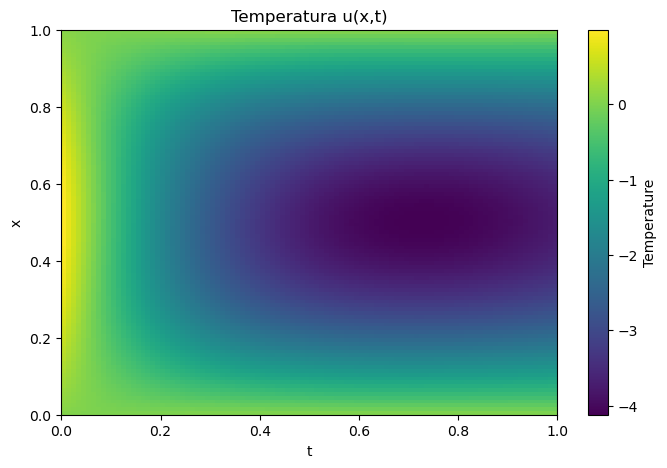

In [ ]:
# =====================================================
# GRID
# =====================================================

Nx = 100
Nt = 100

x = torch.linspace(0,1,Nx)
t = torch.linspace(0,1,Nt)

X, T = torch.meshgrid(x,t, indexing='ij')

# Flatten para alimentar la red
X_flat = X.reshape(-1,1)
T_flat = T.reshape(-1,1)

# =====================================================
# PREDICCIÓN DE u(x,t)
# =====================================================

with torch.no_grad():

    U_pred = u_model(X_flat, T_flat)

# Volver a forma matricial
U_pred = U_pred.reshape(Nx,Nt)

# =====================================================
# PLOT
# =====================================================

plt.figure(figsize=(8,5))

plt.imshow(
    U_pred.numpy(),
    extent=[0,1,0,1],
    origin='lower',
    aspect='auto'
)

plt.colorbar(label='Temperatura')

plt.xlabel("t")
plt.ylabel("x")

plt.title("Temperatura u(x,t)")

plt.show()

Modelo de temperatura sin considerar el control


Epoch: 0

Total Loss: 9.000403
PDE Loss: 0.001455
IC Loss: 0.887688
BC Loss: 0.122071


Epoch: 500

Total Loss: 8.588690
PDE Loss: 0.001460
IC Loss: 0.846554
BC Loss: 0.121693


Epoch: 1000

Total Loss: 8.311255
PDE Loss: 0.001459
IC Loss: 0.818792
BC Loss: 0.121875


Epoch: 1500

Total Loss: 8.674115
PDE Loss: 0.001475
IC Loss: 0.854964
BC Loss: 0.122999


Epoch: 2000

Total Loss: 8.652029
PDE Loss: 0.001479
IC Loss: 0.852948
BC Loss: 0.121070


Epoch: 2500

Total Loss: 8.553133
PDE Loss: 0.001452
IC Loss: 0.843015
BC Loss: 0.121536


Epoch: 3000

Total Loss: 7.597533
PDE Loss: 0.001456
IC Loss: 0.747470
BC Loss: 0.121378


Epoch: 3500

Total Loss: 9.118439
PDE Loss: 0.001467
IC Loss: 0.899529
BC Loss: 0.121685


Epoch: 4000

Total Loss: 8.472852
PDE Loss: 0.001477
IC Loss: 0.835007
BC Loss: 0.121309


Epoch: 4500

Total Loss: 8.551307
PDE Loss: 0.001477
IC Loss: 0.842829
BC Loss: 0.121544



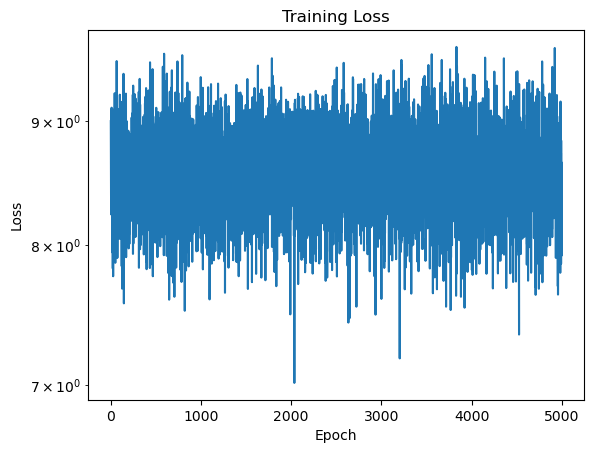

In [ ]:
u_pde = PINN()

optimizer_pde = torch.optim.Adam(
    list(u_pde.parameters()),
    lr=lr
)


# =====================================================
# TRAINING LOOP
# =====================================================

loss_history = []

for epoch in range(epochs):

    optimizer_pde.zero_grad()

    # =================================================
    # 1. COLLOCATION POINTS (INTERIOR)
    # =================================================

    x_f = torch.rand(N_f,1, requires_grad=True)
    t_f = torch.rand(N_f,1, requires_grad=True)

    # Forward pass
    u_pred_pde = u_pde(x_f,t_f)

    # =================================================
    # DERIVADAS
    # =================================================

    u_t_pde = torch.autograd.grad(
        u_pred_pde,
        t_f,
        grad_outputs=torch.ones_like(u_pred_pde),
        create_graph=True
    )[0]

    u_x_pde = torch.autograd.grad(
        u_pred_pde,
        x_f,
        grad_outputs=torch.ones_like(u_pred_pde),
        create_graph=True
    )[0]

    u_xx_pde = torch.autograd.grad(
        u_x_pde,
        x_f,
        grad_outputs=torch.ones_like(u_x_pde),
        create_graph=True
    )[0]

    # =================================================
    # Residuo de la EDP
    # =================================================

    residual = u_t_pde - alpha*u_xx_pde 

    loss_pde = torch.mean(residual**2)

    # =================================================
    # 2. Condiciones iniciales
    # =================================================

    x_i = torch.rand(N_i,1)
    t_i = torch.zeros(N_i,1)

    u_i_true = torch.sin(torch.pi*x_i)

    u_i_pred = u_pde(x_i,t_i)

    loss_ic = torch.mean((u_i_pred - u_i_true)**2)

    # =================================================
    # 3. Condiciones de frontera
    # =================================================

    t_b = torch.rand(N_b,1)

    # x = 0
    x_b0 = torch.zeros(N_b,1)

    # x = 1
    x_b1 = torch.ones(N_b,1)

    u_b0 = u_pde(x_b0,t_b)
    u_b1 = u_pde(x_b1,t_b)

    loss_bc = (
        torch.mean(u_b0**2)
        +
        torch.mean(u_b1**2)
    )

      

    # =================================================
    # 7. Función total de pérdida
    # =================================================

    loss = (
        lambda_pde*loss_pde
        + lambda_ic*loss_ic
        + lambda_bc*loss_bc
    )

    # =================================================
    # BACKWARD Y OPTIMIZACIÓN
    # =================================================

    loss.backward()

    optimizer.step()

    loss_history.append(loss.item())

    # =================================================
    # PRINT
    # =================================================

    if epoch % 500 == 0:

        print(f"""
Epoch: {epoch}

Total Loss: {loss.item():.6f}
PDE Loss: {loss_pde.item():.6f}
IC Loss: {loss_ic.item():.6f}
BC Loss: {loss_bc.item():.6f}
""")

# =====================================================
# LOSS HISTORY
# =====================================================

plt.plot(loss_history)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss")
plt.yscale("log")
plt.show()

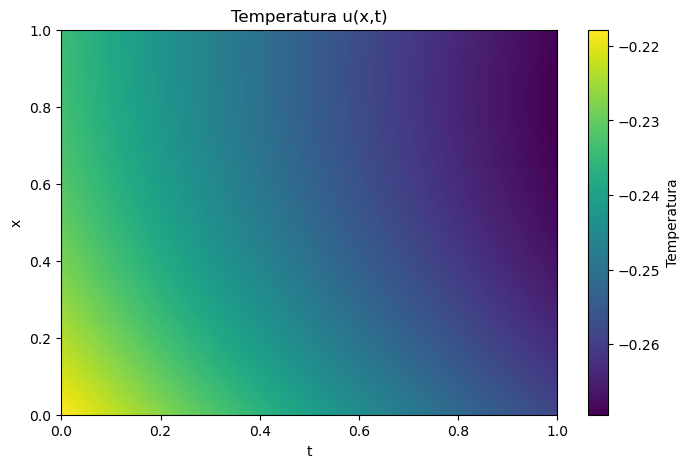

: 

In [ ]:
# =====================================================
# GRID
# =====================================================

Nx = 100
Nt = 100

x = torch.linspace(0,1,Nx)
t = torch.linspace(0,1,Nt)

X, T = torch.meshgrid(x,t, indexing='ij')

# Flatten para alimentar la red
X_flat = X.reshape(-1,1)
T_flat = T.reshape(-1,1)

# =====================================================
# PREDICCIÓN DE u(x,t)
# =====================================================

with torch.no_grad():

    U_pred = u_pde(X_flat, T_flat)

# Volver a forma matricial
U_pred = U_pred.reshape(Nx,Nt)

# =====================================================
# PLOT
# =====================================================

plt.figure(figsize=(8,5))

plt.imshow(
    U_pred.numpy(),
    extent=[0,1,0,1],
    origin='lower',
    aspect='auto'
)

plt.colorbar(label='Temperatura')

plt.xlabel("t")
plt.ylabel("x")

plt.title("Temperatura u(x,t)")

plt.show()